In [7]:
import arviz as az
from risk_experiment.cogmodels.fit_model import build_model, get_data
import pandas as pd
import matplotlib.pyplot as plt

In [11]:
def get_model_info(model_label):
    df = get_data(session=None, bids_folder='/data/ds-risk', model_label=model_label, roi=None)
    model = build_model(df=df, model_label=model_label, roi=None)
    idata = az.from_netcdf(f'/data/ds-risk/derivatives/cogmodels/model-{model_label}_trace.netcdf')    

    return idata, model, df


def get_hdi(x, hdi_prob=0.95):
    return pd.Series(az.hdi(x.values, hdi_prob=hdi_prob), index=['hdi_lower', 'hdi_upper']).T

# g = sns.FacetGrid(data=tmp.reset_index(), col='n_safe', hue='risky_first', col_wrap=6, height=4., aspect=1., )

# g.map_dataframe(sg = sns.FacetGrid(data=tmp.reset_index(), col='n_safe', hue='risky_first', col_wrap=6, height=4., aspect=1., )

# g = sns.catplot(x='bin(risky/safe)', y='chose_risky_pred', data=tmp.reset_index(), kind='point', 
#                 hue='risky_first', col='bin(n_safe)', errorbar=None, height=4., aspect=1.)

def plot_hdi(data, x, y, **kwargs):
    import matplotlib.pyplot as plt
    hdi = data.groupby(x)[y].apply(lambda x: get_hdi(x)).unstack()
    plt.fill_between(x=data[x].unique(), y1=hdi['hdi_lower'], y2=hdi['hdi_upper'], **kwargs)

In [4]:
model_label = '12'
df = get_data(session=None, bids_folder='/data/ds-risk', model_label=model_label, roi=None)
model = build_model(df=df, roi=None,model_label=model_label)
idata = az.from_netcdf(f'/data/ds-risk/derivatives/cogmodels/model-{model_label}_trace.netcdf')

100%|██████████| 30/30 [00:02<00:00, 11.25it/s]


In [5]:
ppc = model.ppc(idata=idata.sel(draw=slice(None, None, 20)), paradigm=df.drop('session',axis=1), var_names=['ll_bernoulli'])
ppc = ppc.stack([0, 1]).to_frame('choice_pred')
ppc = ppc.reset_index().set_index(df.index.names + ['chain', 'draw'])[['choice_pred']]
ppc = ppc.join(df[['risky_first', 'n_risky', 'n_safe', 'chose_risky']])

ppc['chose_risky_pred'] = ppc['choice_pred'].where(~ppc['risky_first'], ~ppc['choice_pred'])

n_bins = 7
ppc['bin(n_safe)'] = pd.qcut(ppc['n_safe'], q=3, labels=['Small', 'Medium', 'Large'])
ppc['bin(risky/safe)'] = ppc.groupby('subject').apply(lambda x: pd.qcut(x['n_risky']/x['n_safe'], q=n_bins, 
                                                                      labels=False, duplicates='drop')).reset_index(level=0, drop=True)


Sampling: [ll_bernoulli]


/Users/gdehol/mambaforge/lib/python3.11/site-packages/rich/live.py:231: UserWarning: install "ipywidgets" for 
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_19103/618554631.py:2: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  ppc = ppc.stack([0, 1]).to_frame('choice_pred')


/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_19103/717880068.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp = ppc.groupby(['subject', 'bin(n_safe)', 'risky_first', 'bin(risky/safe)', 'chain', 'draw'])[['chose_risky_pred']].mean()
/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_19103/717880068.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp = ppc.groupby(['bin(n_safe)', 'risky_first', 'bin(risky/safe)', 'chain', 'draw'])[['chose_risky_pred', 'chose_risky']].mean()


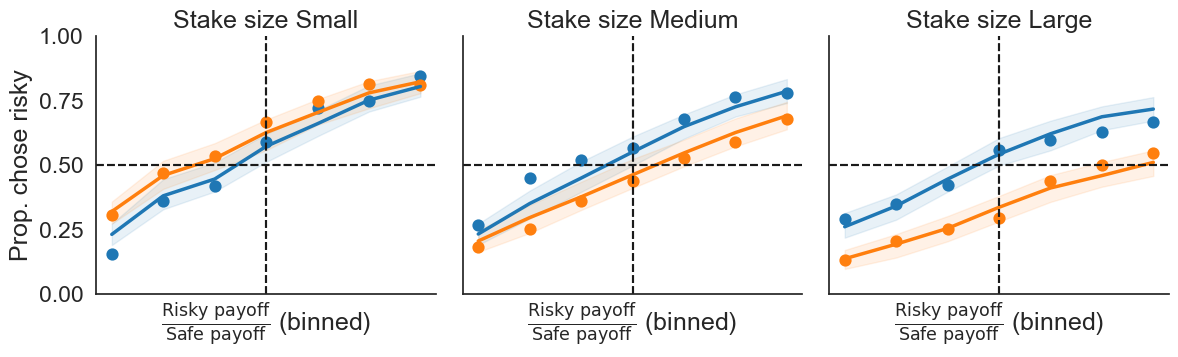

In [6]:
import seaborn as sns

palette = sns.color_palette()
sns.set(style='white', font_scale=1.5)
sns.set_palette(palette)

tmp = ppc.groupby(['subject', 'bin(n_safe)', 'risky_first', 'bin(risky/safe)', 'chain', 'draw'])[['chose_risky_pred']].mean()
tmp = ppc.groupby(['bin(n_safe)', 'risky_first', 'bin(risky/safe)', 'chain', 'draw'])[['chose_risky_pred', 'chose_risky']].mean()

# sns.catplot(x='bin(risky/safe)', y='chose_risky_pred', data=ppc.reset_index(), kind='point', 
#                 hue='risky_first', col='bin(n_safe)', errorbar=None, height=4., aspect=1.)


def get_hdi(x, hdi_prob=0.95):
    return pd.Series(az.hdi(x.values, hdi_prob=hdi_prob), index=['hdi_lower', 'hdi_upper']).T

# g = sns.FacetGrid(data=tmp.reset_index(), col='n_safe', hue='risky_first', col_wrap=6, height=4., aspect=1., )

# g.map_dataframe(sg = sns.FacetGrid(data=tmp.reset_index(), col='n_safe', hue='risky_first', col_wrap=6, height=4., aspect=1., )

# g = sns.catplot(x='bin(risky/safe)', y='chose_risky_pred', data=tmp.reset_index(), kind='point', 
#                 hue='risky_first', col='bin(n_safe)', errorbar=None, height=4., aspect=1.)

def plot_hdi(data, x, y, **kwargs):
    import matplotlib.pyplot as plt
    hdi = data.groupby(x)[y].apply(lambda x: get_hdi(x)).unstack()
    plt.fill_between(x=data[x].unique(), y1=hdi['hdi_lower'], y2=hdi['hdi_upper'], **kwargs)

g = sns.FacetGrid(data=tmp.reset_index(), col='bin(n_safe)', hue='risky_first', height=4., aspect=1., )
g.map_dataframe(plot_hdi, x='bin(risky/safe)', y='chose_risky_pred', alpha=0.1, )
g.map_dataframe(sns.pointplot, 'bin(risky/safe)', 'chose_risky', marker='o',   linestyles="")
g.map_dataframe(sns.lineplot, 'bin(risky/safe)', 'chose_risky_pred', marker='x', err_style=None, lw=2.5, markersize=10, markeredgecolor='none')

g.map(plt.axhline, y=0.5, c='k', ls='--')
g.map(plt.axvline, x=3, c='k', ls='--')

g.set_titles(f'Stake size {{col_name}}')
g.set(xlabel=r'$\frac{\mathrm{Risky\ payoff}}{\mathrm{Safe\ payoff}}$ (binned)', ylabel='Prop. chose risky', xticks=[], yticks=[0, .25, .5, .75, 1.])

# g.map_dataframe(sns.pointplot, 'bin(risky/safe)', 'chose_risky_pred', dodge=0.3)ns.pointplot, x='bin(risky/safe)', y='chose_risky_pred', dodge=0.3)

palette = sns.color_palette()
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Risky First',
           markerfacecolor=palette[1], markersize=10, linestyle='None'),
    Line2D([0], [0], marker='o', color='w', label='Safe First',
           markerfacecolor=palette[0], markersize=10, linestyle='None')
]

# Add legend to the figure (not the FacetGrid)
# g.fig.legend(
#     handles=legend_elements,
#     loc='upper center',
#     ncol=1,
#     bbox_to_anchor=(1.1, 0.75)  # Adjust position as neededGo

# )


g.savefig('/data/ds-risk/derivatives/figures/ppc_stake_choice.pdf', bbox_inches='tight')

In [24]:
import seaborn as sns

palette = sns.color_palette()
sns.set(style='white', font_scale=1.5)
sns.set_palette(palette)

def plot_ppc(ppc, gray=False):


    tmp = ppc.groupby(['subject', 'bin(n_safe)', 'risky_first', 'bin(risky/safe)', 'chain', 'draw'])[['chose_risky_pred']].mean()
    tmp = ppc.groupby(['bin(n_safe)', 'risky_first', 'bin(risky/safe)', 'chain', 'draw'])[['chose_risky_pred', 'chose_risky']].mean()

    def get_hdi(x, hdi_prob=0.95):
        return pd.Series(az.hdi(x.values, hdi_prob=hdi_prob), index=['hdi_lower', 'hdi_upper']).T

    # g = sns.FacetGrid(data=tmp.reset_index(), col='n_safe', hue='risky_first', col_wrap=6, height=4., aspect=1., )

    # g.map_dataframe(sg = sns.FacetGrid(data=tmp.reset_index(), col='n_safe', hue='risky_first', col_wrap=6, height=4., aspect=1., )

    # g = sns.catplot(x='bin(risky/safe)', y='chose_risky_pred', data=tmp.reset_index(), kind='point', 
    #                 hue='risky_first', col='bin(n_safe)', errorbar=None, height=4., aspect=1.)

    def plot_hdi(data, x, y, **kwargs):
        import matplotlib.pyplot as plt
        hdi = data.groupby(x)[y].apply(lambda x: get_hdi(x)).unstack()
        plt.fill_between(x=data[x].unique(), y1=hdi['hdi_lower'], y2=hdi['hdi_upper'], **kwargs)


    color = 'gray' if gray else None
    
    g = sns.FacetGrid(data=tmp.reset_index(), col='bin(n_safe)', hue='risky_first', height=4., aspect=1., )

    g.map_dataframe(plot_hdi, x='bin(risky/safe)', y='chose_risky_pred', alpha=0.1, color=color)
    g.map_dataframe(sns.pointplot, 'bin(risky/safe)', 'chose_risky', marker='o',   linestyles="")
    g.map_dataframe(sns.lineplot, 'bin(risky/safe)', 'chose_risky_pred', marker='x', err_style=None, lw=2.5, markersize=10, markeredgecolor='none', color=color)

    g.map(plt.axhline, y=0.5, c='k', ls='--')
    g.map(plt.axvline, x=3, c='k', ls='--')

    g.set_titles(f'Stake size {{col_name}}')
    g.set(xlabel=r'$\frac{\mathrm{Risky\ payoff}}{\mathrm{Safe\ payoff}}$ (binned)', ylabel='Prop. chose risky', xticks=[], yticks=[0, .25, .5, .75, 1.])

    # g.map_dataframe(sns.pointplot, 'bin(risky/safe)', 'chose_risky_pred', dodge=0.3)ns.pointplot, x='bin(risky/safe)', y='chose_risky_pred', dodge=0.3)

    palette = sns.color_palette()
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', label='Risky First',
            markerfacecolor=palette[1], markersize=10, linestyle='None'),
        Line2D([0], [0], marker='o', color='w', label='Safe First',
            markerfacecolor=palette[0], markersize=10, linestyle='None')
    ]

def get_ppc(model):
    ppc = model.ppc(idata=idata.sel(draw=slice(None, None, 20)), paradigm=df.drop('session',axis=1), var_names=['ll_bernoulli'])
    ppc = ppc.stack([0, 1]).to_frame('choice_pred')
    ppc = ppc.reset_index().set_index(df.index.names + ['chain', 'draw'])[['choice_pred']]
    ppc = ppc.join(df[['risky_first', 'n_risky', 'n_safe', 'chose_risky']])

    ppc['chose_risky_pred'] = ppc['choice_pred'].where(~ppc['risky_first'], ~ppc['choice_pred'])

    n_bins = 7
    ppc['bin(n_safe)'] = pd.qcut(ppc['n_safe'], q=3, labels=['Small', 'Medium', 'Large'])
    ppc['bin(risky/safe)'] = ppc.groupby('subject').apply(lambda x: pd.qcut(x['n_risky']/x['n_safe'], q=n_bins, 
                                                                        labels=False, duplicates='drop')).reset_index(level=0, drop=True)
    return ppc

# Model A

In [89]:
models_labels = [('klw', 'Model A: Shared prior, equal noise', True),
          ('12', 'PMC model', False),
          ('42', 'Model C: Shared prior, varying noise', False),
          ('52', 'Model B: Varying priors, equal noise', True),
          ('eu', 'Model D: Expected utility model', True)]

idatas = {}
models = {}

  0%|          | 0/30 [00:00<?, ?it/s]

100%|██████████| 30/30 [00:12<00:00,  2.42it/s]
Sampling: [ll_bernoulli]


/Users/gdehol/mambaforge/lib/python3.11/site-packages/rich/live.py:231: UserWarning: install "ipywidgets" for 
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_19103/2849665273.py:56: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  ppc = ppc.stack([0, 1]).to_frame('choice_pred')
/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_19103/2849665273.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp = ppc.groupby(['subject', 'bin(n_safe)', 'risky_first', 'bin(risky/safe)', 'chain', 'draw'])[['chose_risky_pred']].mean()
/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_19103/2849665273.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to

/Users/gdehol/mambaforge/lib/python3.11/site-packages/rich/live.py:231: UserWarning: install "ipywidgets" for 
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

...

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_19103/2849665273.py:56: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  ppc = ppc.stack([0, 1]).to_frame('choice_pred')
/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_19103/2849665273.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp = ppc.groupby(['subject', 'bin(n_safe)', 'risky_first', 'bin(risky/safe)', 'chain', 'draw'])[['chose_risky_pred']].mean()
/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_19103/2849665273.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to

/Users/gdehol/mambaforge/lib/python3.11/site-packages/rich/live.py:231: UserWarning: install "ipywidgets" for 
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_19103/2849665273.py:56: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  ppc = ppc.stack([0, 1]).to_frame('choice_pred')
/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_19103/2849665273.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp = ppc.groupby(['subject', 'bin(n_safe)', 'risky_first', 'bin(risky/safe)', 'chain', 'draw'])[['chose_risky_pred']].mean()
/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_19103/2849665273.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to

/Users/gdehol/mambaforge/lib/python3.11/site-packages/rich/live.py:231: UserWarning: install "ipywidgets" for 
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_19103/2849665273.py:56: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  ppc = ppc.stack([0, 1]).to_frame('choice_pred')
/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_19103/2849665273.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp = ppc.groupby(['subject', 'bin(n_safe)', 'risky_first', 'bin(risky/safe)', 'chain', 'draw'])[['chose_risky_pred']].mean()
/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_19103/2849665273.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to

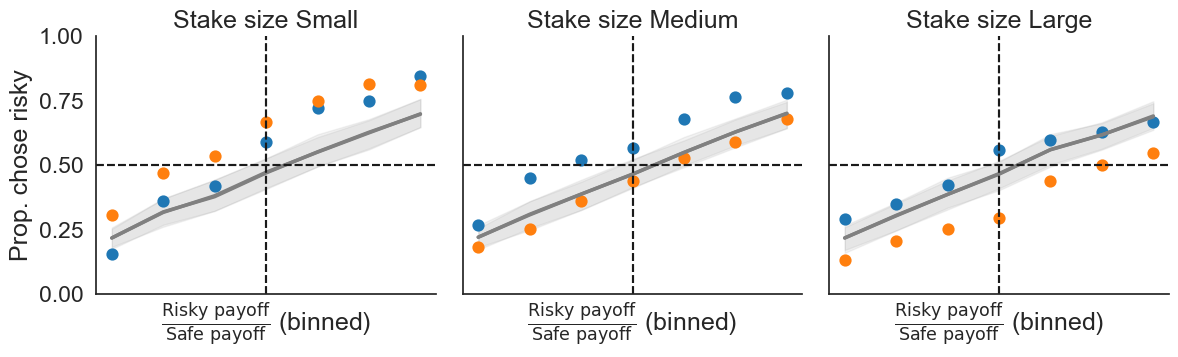

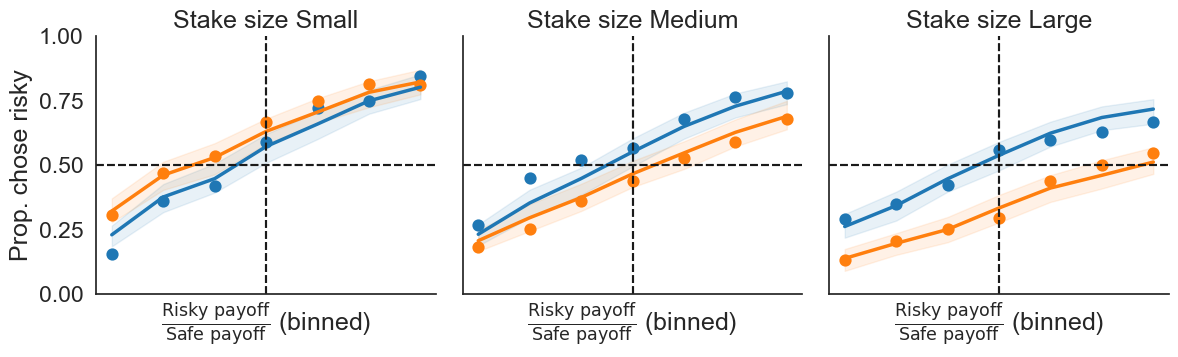

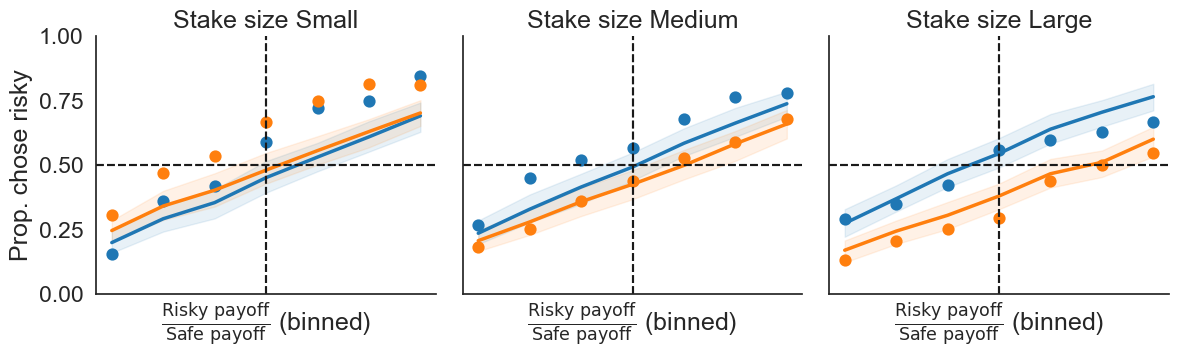

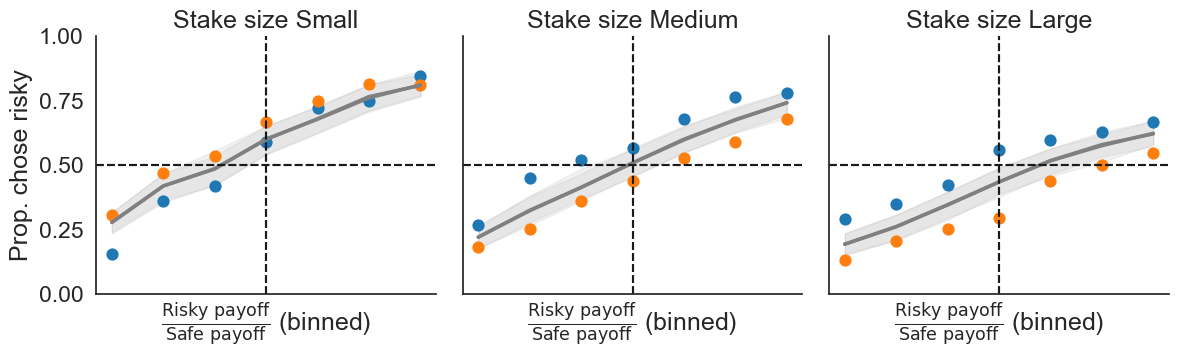

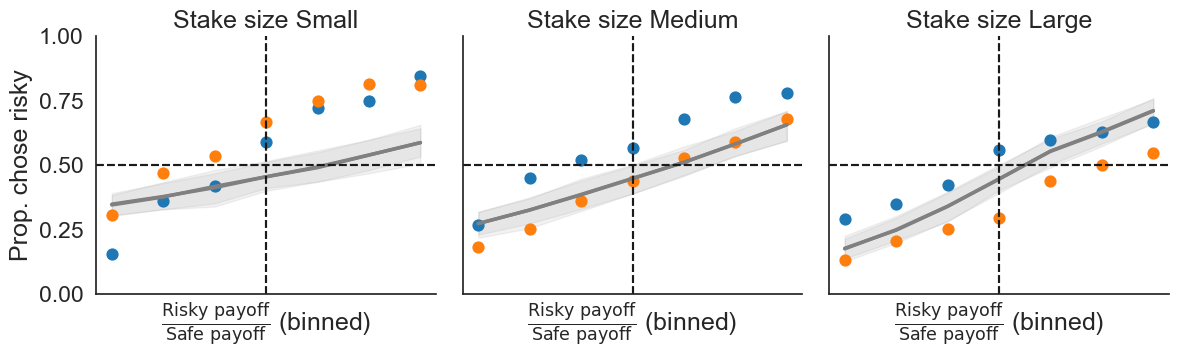

In [90]:
for model_label, model_name, gray in models_labels:
    idata, model, df = get_model_info(model_label=model_label)
    ppc = get_ppc(model)
    plot_ppc(ppc, gray=gray)

    idatas[model_name] = idata
    models[model_name] = model
    # plt.suptitle(model_name, y=1.05)
    plt.savefig(f'/data/ds-risk/derivatives/figures/ppc_stake_choice_{model_label}.pdf', bbox_inches='tight')

In [91]:
import pymc as pm

In [92]:
for key, model in models.items():
    idata = idatas.get(key)
    if idata is None:
        print(f"Skipping {key}: no idata available")
        continue
    try:
        with model.estimation_model:
            ll = pm.compute_log_likelihood(idata)
        if ll is not None:
            try:
                idata.add_groups({'log_likelihood': ll})
            except Exception:
                # fallback: keep idata as-is (some InferenceData objects already contain log_likelihood)
                idatas[key] = idata
    except Exception as e:
        print(f"Could not compute log likelihood for model {key}: {e}")

/Users/gdehol/mambaforge/lib/python3.11/site-packages/rich/live.py:231: UserWarning: install "ipywidgets" for 
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/Users/gdehol/mambaforge/lib/python3.11/site-packages/rich/live.py:231: UserWarning: install "ipywidgets" for 
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/Users/gdehol/mambaforge/lib/python3.11/site-packages/rich/live.py:231: UserWarning: install "ipywidgets" for 
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/Users/gdehol/mambaforge/lib/python3.11/site-packages/rich/live.py:231: UserWarning: install "ipywidgets" for 
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/Users/gdehol/mambaforge/lib/python3.11/site-packages/rich/live.py:231: UserWarning: install "ipywidgets" for 
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Could not compute log likelihood for model Model D: Expected utility model: ['log_likelihood'] group(s) already exists.


In [93]:
comparison = az.compare(idatas)

/Users/gdehol/mambaforge/lib/python3.11/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/Users/gdehol/mambaforge/lib/python3.11/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


In [94]:
comparison

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
PMC model,0,-5894.572241,198.954967,0.000000,9.420019e-01,53.324233,0.000000,True,log
"Model B: Varying priors, equal noise",1,-6115.663668,131.715387,221.091427,5.134139e-02,51.460785,21.751930,False,log
"Model C: Shared prior, varying noise",2,-6588.096530,137.234336,693.524289,6.656741e-03,46.015107,34.268395,False,log
"Model A: Shared prior, equal noise",3,-6735.814035,77.957129,841.241794,0.000000e+00,43.938969,37.606553,False,log
Model D: Expected utility model,4,-6828.239123,101.902186,933.666883,6.270762e-10,42.641088,38.705213,True,log


/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_19103/2256225886.py:4: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


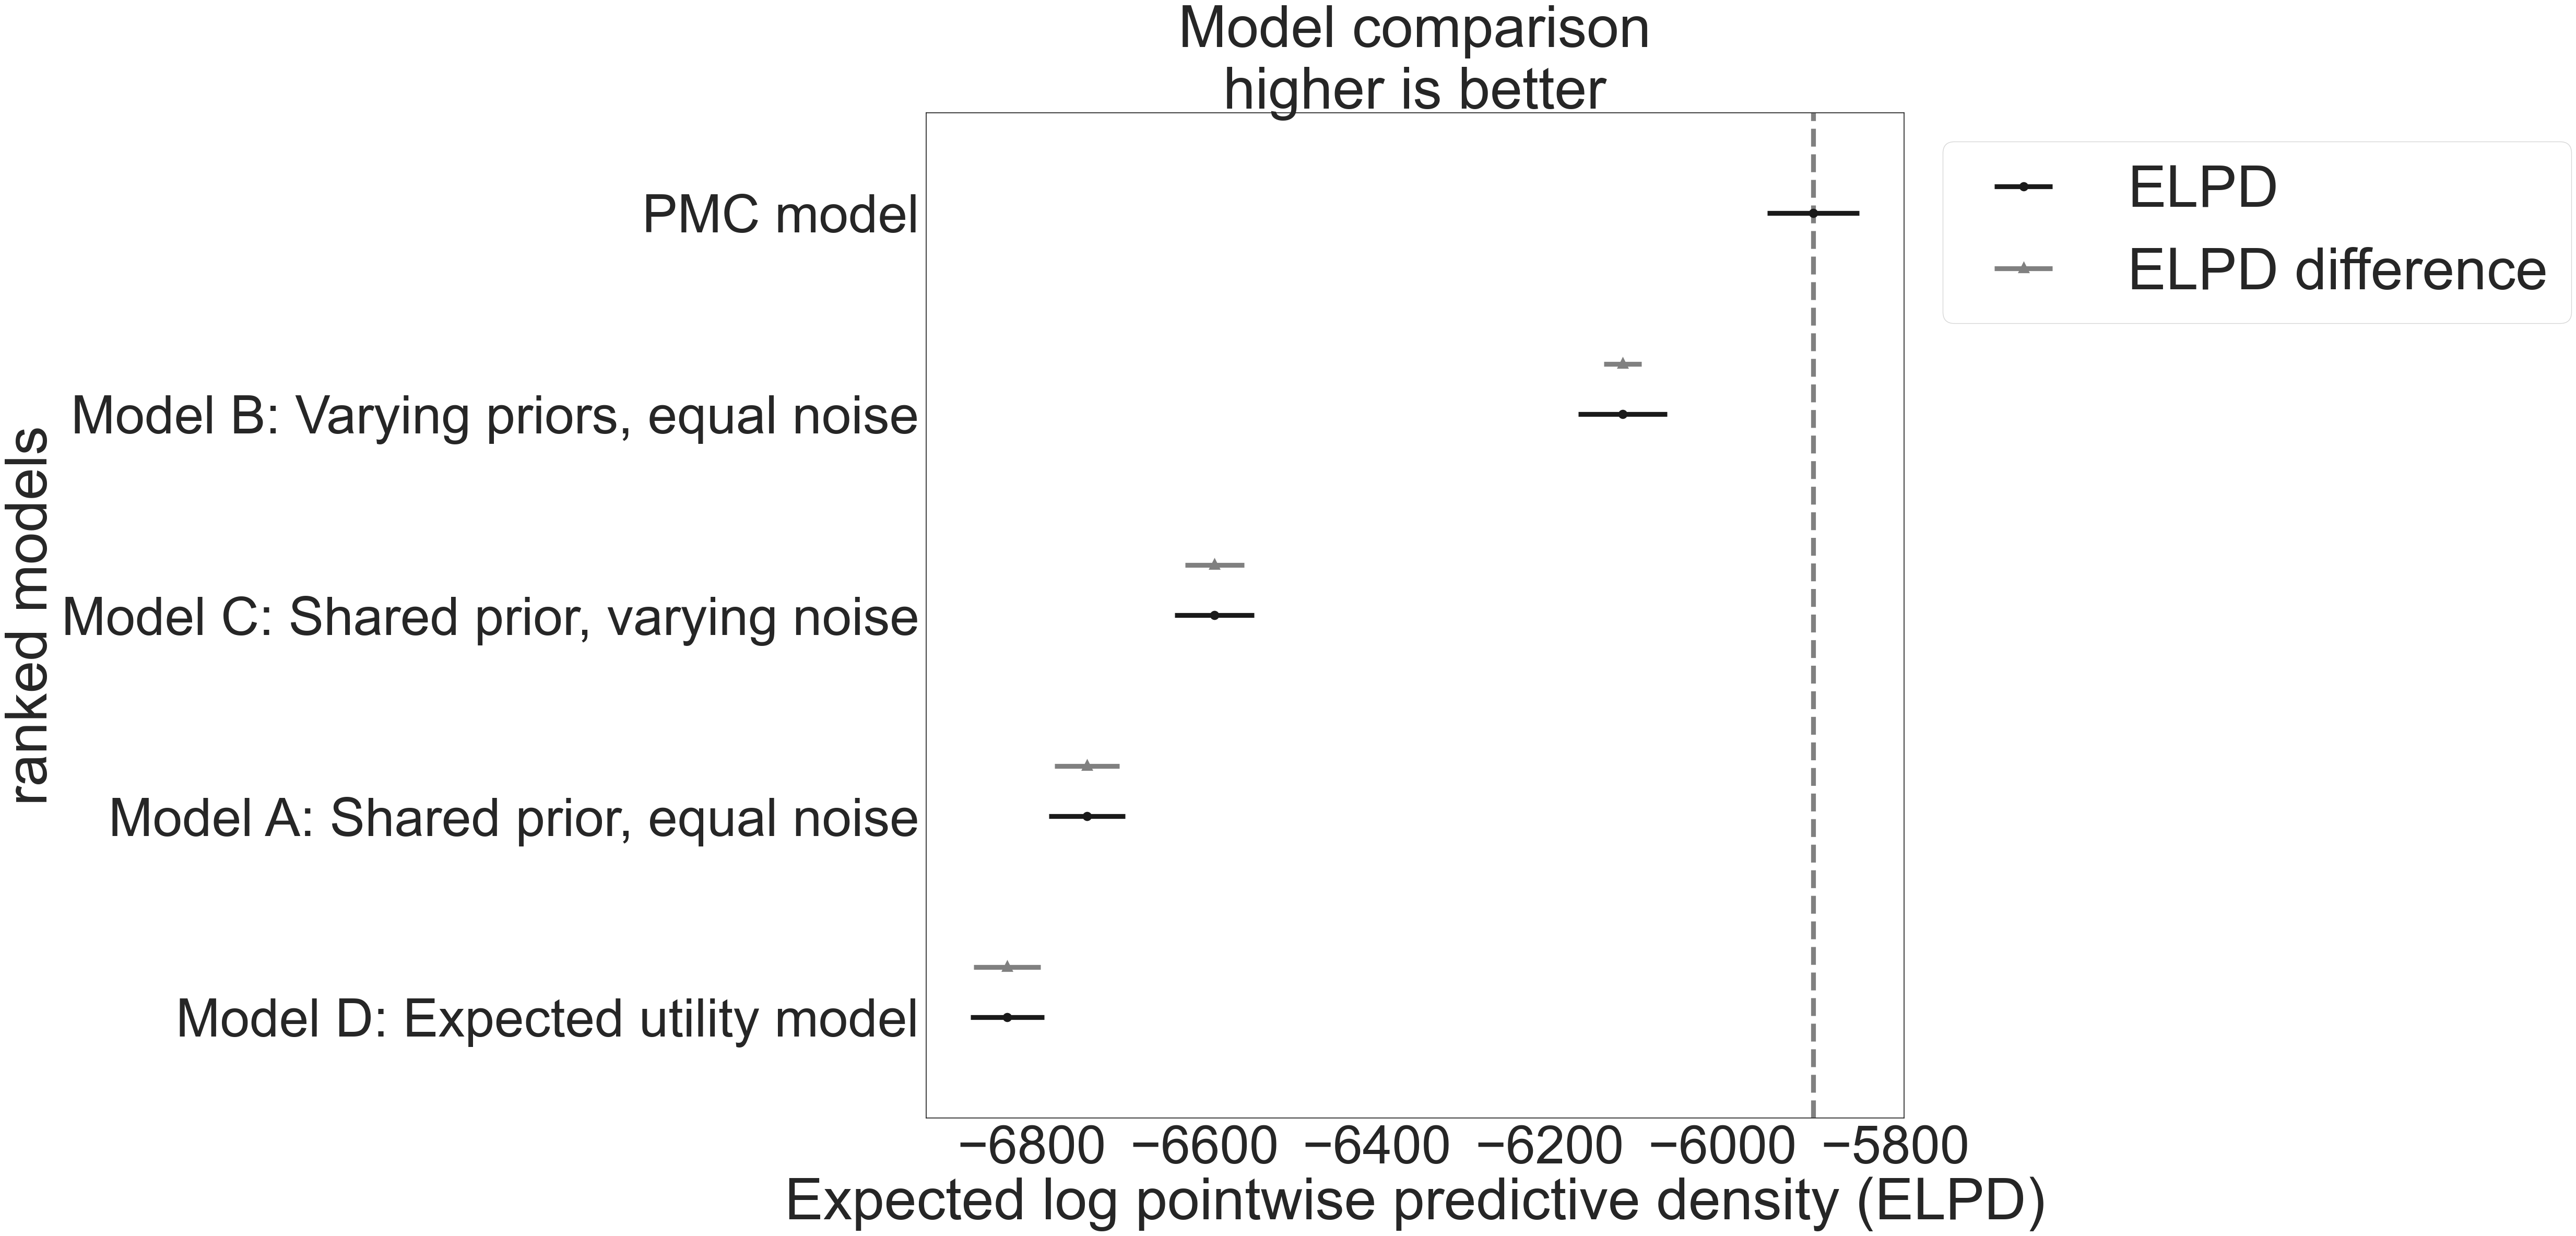

In [ ]:
ax = az.plot_compare(comparison, figsize=(290/12, 300/12), legend=True, plot_ic_diff=True)

ax.set_xlabel('Expected log pointwise predictive density (ELPD)',)
plt.tight_layout()
ax.figure.savefig('/data/ds-risk/derivatives/figures/model_comparison.pdf', bbox_inches='tight')

# move the legend to inside the axis, top left
